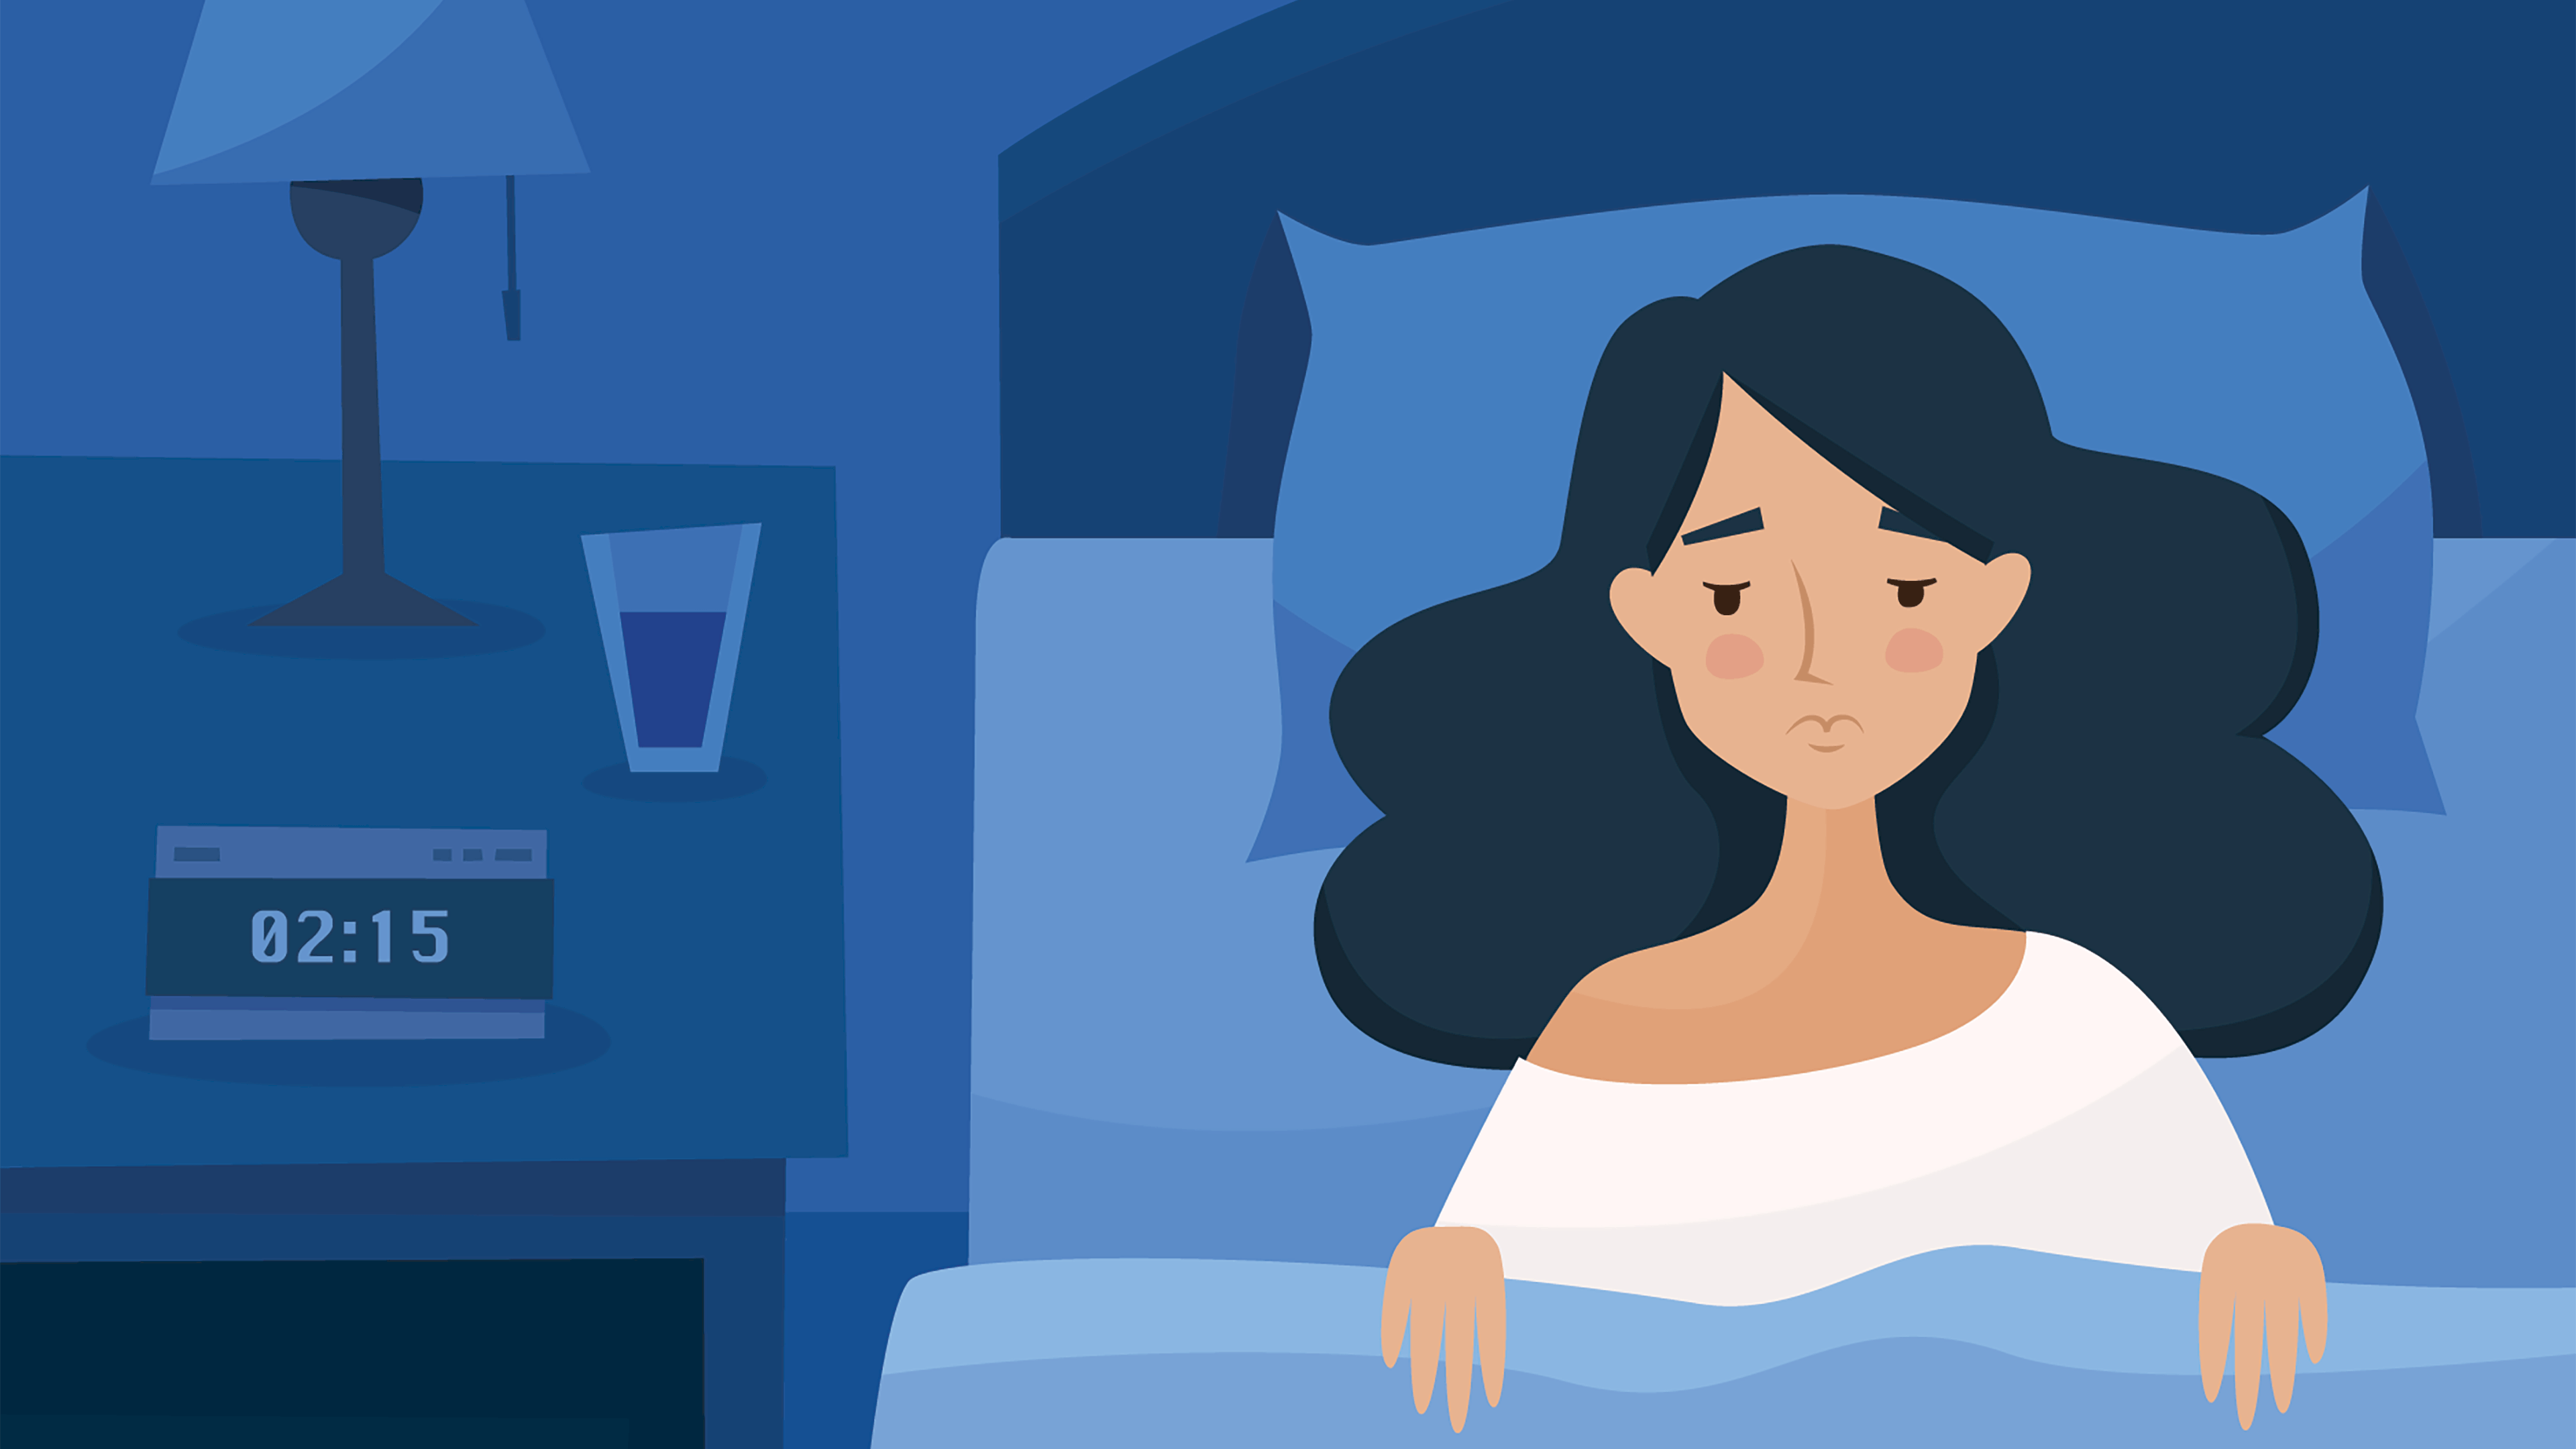

# **Objetivo del trabajo**
Desarrollar un análisis exploratorio sobre los patrones de sueño y estilo de vida, utilizando un dataset con variables fisiológicas, conductuales y demográficas. El objetivo es identificar qué factores tienen mayor impacto en la calidad del sueño y en la aparición de trastornos como insomnio o apnea. Se complementa el análisis con visualizaciones en Python que permitan responder preguntas clave y establecer hipótesis sobre el vínculo entre estrés, actividad física, duración del sueño y salud general.

# **Preguntas e hipótesis de interés**
*   ¿El nivel de estrés es un mejor predictor de trastornos del sueño que la duración del sueño?

    *Hipótesis*: El estrés elevado está más fuertemente asociado a la presencia de trastornos del sueño que la cantidad de horas dormidas
*   ¿La actividad física elevada mejora la calidad del sueño en todos los perfiles, o existen grupos donde el efecto es inverso?

    *Hipótesis*: La actividad física mejora la calidad del sueño en general, pero su efecto puede variar según edad, género o nivel de estrés.
*   ¿Las personas con trastornos del sueño presentan patrones fisiológicos distintos (frecuencia cardíaca, pasos diarios)?

    *Hipótesis*: Las personas que sufren de insomnio o apnea muestran diferencias significativas en variables como frecuencia cardíaca y cantidad de pasos diarios
*  ¿Las personas con ocupaciones más demandantes presentan mayor estrés y peor descanso?

    *Hipótesis*: Las ocupaciones de alta exigencia laboral están asociadas a mayor estrés y menor duración/calidad del sueño.

# **Descripción del dataset**
Se trata de un conjunto de datos con 374 registros individuales. Cada fila representa una persona con atributos relacionados al estilo de vida, salud y sueño. Las variables incluyen:

* Person ID: identificador único.
* Gender: género.
* Age: edad.
* Occupation: ocupación.
* Sleep Duration: duración promedio del sueño (en horas).
* Quality of Sleep: calidad del sueño (escala numérica).
* Physical Activity Level: nivel de actividad física.
* Stress Level: nivel de estrés reportado.
* BMI Category: categoría de índice de masa corporal.
* Blood Pressure: presión arterial.
* Heart Rate: frecuencia cardíaca.
* Daily Steps: cantidad de pasos diarios.
* Sleep Disorder: tipo de trastorno del sueño (insomnio, apnea, ninguno).

Data Source: [Lifestyle & Sleep Patterns - Kaggle](https://www.kaggle.com/datasets/minahilfatima12328/lifestyle-and-sleep-patterns?resource=download)



---


# **Parte Práctica**

##Importación de Librerías

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Personalización
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## Carga del DataSet utilizando una API

In [46]:
# Es necesario instalar kagglehub
!pip install kagglehub -q

import kagglehub
import os

# Esto permite descargarar la versión más reciente del dataset
dataset_handle = "minahilfatima12328/lifestyle-and-sleep-patterns"

print("Descargando dataset desde Kaggle...")
path = kagglehub.dataset_download(dataset_handle)

print("Ruta del dataset descargado:", path)

# Listar archivos para ver cuál es el CSV
archivos = os.listdir(path)
print("Archivos en la carpeta:", archivos)

csv_filename = "Sleep_health_and_lifestyle_dataset.csv"

ruta_csv = os.path.join(path, csv_filename)

# Cargar el DataFrame
df_sleep = pd.read_csv(ruta_csv)

print("Dataset cargado exitosamente!")
print("Filas y columnas:", df_sleep.shape)
print(df_sleep.head())


Descargando dataset desde Kaggle...
Using Colab cache for faster access to the 'lifestyle-and-sleep-patterns' dataset.
Ruta del dataset descargado: /kaggle/input/lifestyle-and-sleep-patterns
Archivos en la carpeta: ['Sleep_health_and_lifestyle_dataset.csv']
Dataset cargado exitosamente!
Filas y columnas: (374, 13)
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8    

##Investigando contenido

In [47]:
# Dimensiones del dataset
print("Filas y columnas:", df_sleep.shape)

# Tipos de datos
print(df_sleep.dtypes)

# Valores nulos
print("Valores perdidos por columna:")
print(df_sleep.isnull().sum())


Filas y columnas: (374, 13)
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object
Valores perdidos por columna:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


In [48]:
#Reemplazando "None" de Sleep Disorder para que no se considere como null value
df_sleep['Sleep Disorder'] = df_sleep['Sleep Disorder'].replace({None: 'No Disorder'})

#Validando que se aplicó correctamente
df_sleep['Sleep Disorder'].value_counts(dropna=False)

,count
Sleep Disorder,
No Disorder,219
Sleep Apnea,78
Insomnia,77


In [49]:
# Limpieza y transformación de datos
# Renombrar columnas para claridad (en español)
df_sleep = df_sleep.rename(columns={
    'Person ID': 'ID_Persona',
    'Gender': 'Género',
    'Age': 'Edad',
    'Occupation': 'Ocupación',
    'Sleep Duration': 'Duración_Sueño',
    'Quality of Sleep': 'Calidad_Sueño',
    'Physical Activity Level': 'Nivel_Actividad_Física',
    'Stress Level': 'Nivel_Estrés',
    'BMI Category': 'Categoría_BMI',
    'Blood Pressure': 'Presión_Arterial',
    'Heart Rate': 'Frecuencia_Cardíaca',
    'Daily Steps': 'Pasos_Diarios',
    'Sleep Disorder': 'Trastorno_Sueño'
})

print(df_sleep.head())

   ID_Persona Género  Edad             Ocupación  Duración_Sueño  \
0           1   Male    27     Software Engineer             6.1   
1           2   Male    28                Doctor             6.2   
2           3   Male    28                Doctor             6.2   
3           4   Male    28  Sales Representative             5.9   
4           5   Male    28  Sales Representative             5.9   

   Calidad_Sueño  Nivel_Actividad_Física  Nivel_Estrés Categoría_BMI  \
0              6                      42             6    Overweight   
1              6                      60             8        Normal   
2              6                      60             8        Normal   
3              4                      30             8         Obese   
4              4                      30             8         Obese   

  Presión_Arterial  Frecuencia_Cardíaca  Pasos_Diarios Trastorno_Sueño  
0           126/83                   77           4200     No Disorder  
1           

#Obtenemos información adicional de la OMS utilizando una API

In [50]:
import requests

#Bloque para importar datos de la API de la OMS (WHO GHO API)
#Indicador: Prevalencia de actividad física insuficiente en adultos (NCD_PAA, age-standardized)
url = "https://ghoapi.azureedge.net/api/NCD_PAA"
print("Conectando con la API de la OMS...")
response = requests.get(url)

if response.status_code == 200:
    data = response.json()['value']
    # Crear DataFrame con los datos relevantes
    df_oms = pd.DataFrame(data)
    # Seleccionar columnas útiles: País, Año, Sexo, Valor numérico
    df_oms = df_oms[['SpatialDim', 'TimeDim', 'Dim1', 'NumericValue']]
    df_oms.columns = ['País', 'Año', 'Sexo', 'Prevalencia_Insuficiente (%)']
    # Filtrar por datos globales o recientes (ej. BOTHSEX, últimos años)
    df_oms = df_oms[(df_oms['Sexo'] == 'BOTHSEX') & (df_oms['Año'] >= 2016)]
    # Guardar en CSV local
    df_oms.to_csv('oms_physical_activity.csv', index=False)
    print("Datos de OMS guardados en 'oms_physical_activity.csv'")
else:
    print("Error al conectar con la API:", response.status_code)


#Cargamos el CSV
df_oms = pd.read_csv('oms_physical_activity.csv')

print("Datos OMS descargados:")
print(df_oms.head(10))

Conectando con la API de la OMS...
Datos de OMS guardados en 'oms_physical_activity.csv'
Datos OMS descargados:
Empty DataFrame
Columns: [País, Año, Sexo, Prevalencia_Insuficiente (%)]
Index: []


#Añadimos datos de la OMS

In [51]:

# OMS recomienda al menos 150 min/semana (~21 min/día), pero dataset usa min/día de actividad.
# Categorizamos: Si Nivel_Actividad_Física >= 30 min/día, "Cumple"
def categorizar_actividad_oms(minutos):
    if minutos >= 30:
        return "Cumple recomendación OMS"
    else:
        return "Bajo recomendación OMS"

df_sleep['OMS_Status'] = df_sleep['Nivel_Actividad_Física'].apply(categorizar_actividad_oms)

# Para sueño: Recomendación 7-9 horas
def categorizar_sueño(horas):
    if 7 <= horas <= 9:
        return "Óptimo"
    elif horas < 7:
        return "Insuficiente"
    else:
        return "Excesivo"

df_sleep['Categoría_Sueño'] = df_sleep['Duración_Sueño'].apply(categorizar_sueño)

# Verificamos que se creó bien
print("\nEjemplo de enriquecimiento:")
print(df_sleep[['Nivel_Actividad_Física', 'OMS_Status', 'Duración_Sueño', 'Categoría_Sueño']].head(10))


# Visualizamos cuántos cumplen los requisitios de la OMS
print("\nCumplimiento OMS:")
print(df_sleep['OMS_Status'].value_counts(normalize=True) * 100)


Ejemplo de enriquecimiento:
   Nivel_Actividad_Física                OMS_Status  Duración_Sueño  \
0                      42  Cumple recomendación OMS             6.1   
1                      60  Cumple recomendación OMS             6.2   
2                      60  Cumple recomendación OMS             6.2   
3                      30  Cumple recomendación OMS             5.9   
4                      30  Cumple recomendación OMS             5.9   
5                      30  Cumple recomendación OMS             5.9   
6                      40  Cumple recomendación OMS             6.3   
7                      75  Cumple recomendación OMS             7.8   
8                      75  Cumple recomendación OMS             7.8   
9                      75  Cumple recomendación OMS             7.8   

  Categoría_Sueño  
0    Insuficiente  
1    Insuficiente  
2    Insuficiente  
3    Insuficiente  
4    Insuficiente  
5    Insuficiente  
6    Insuficiente  
7          Óptimo  
8        

## Visualizaciones **univariadas**

## Histograma - Duración del sueño
La mayoría de los participantes duermen entre 6 y 8 horas, lo que coincide con las recomendaciones generales. Sin embargo, hay casos extremos que duermen menos de 5 o más de 9 horas, lo que podría estar vinculado a trastornos del sueño o estilos de vida particulares.

In [52]:
# Histograma de duración del sueño
sns.histplot(df_sleep["Sleep Duration"], bins=20, kde=True)
plt.title("Distribución de horas de sueño")
plt.xlabel("Horas de sueño")
plt.ylabel("Frecuencia")
plt.show()



KeyError: 'Sleep Duration'

## Boxplot - Nivel de estrés
El estrés muestra una distribución amplia, con muchos casos en niveles altos. Esto sugiere que el estrés es una variable crítica a considerar en el análisis de calidad del sueño y posibles trastornos.

In [ ]:
# Boxplot univariado del nivel de estrés
sns.boxplot(x=df_sleep["Stress Level"], color="skyblue")
plt.title("Distribución del nivel de estrés")
plt.xlabel("Nivel de estrés")
plt.show()


##Visualizaciones **bivariadas**

## Scatterplot - Duración vs calidad del sueño (con estrés)
Se observa una relación positiva entre duración y calidad del sueño, especialmente en niveles bajos de estrés. A medida que el estrés aumenta, la calidad del sueño tiende a disminuir, incluso si la duración se mantiene.

In [ ]:
# Relación entre duración del sueño y calidad del sueño
sns.scatterplot(data=df_sleep, x="Sleep Duration", y="Quality of Sleep", hue="Stress Level", palette="coolwarm")
plt.title("Duración vs Calidad del sueño")
plt.show()


## Boxplot- Frecuencia cardíaca por tipo de trastorno
Las personas con apnea presentan mayor frecuencia cardíaca promedio, lo que podría reflejar alteraciones fisiológicas durante el sueño. En cambio, quienes no tienen trastornos muestran valores más estables.



In [ ]:
#Gráficos de frecuencia cardíaca y pasos por tipo de trastorno
sns.boxplot(data=df_sleep, x="Sleep Disorder", y="Heart Rate", hue="Sleep Disorder", palette="pastel", legend=False)
plt.title("Frecuencia cardíaca por tipo de trastorno del sueño")
plt.show()


## Boxplot- Pasos diarios por tipo de trastorno
Las personas sin trastornos tienden a tener mayor cantidad de pasos diarios, lo que sugiere que la actividad física podría estar asociada a mejor descanso. Los casos de insomnio y apnea muestran menor movilidad.

In [ ]:
sns.boxplot(data=df_sleep, x="Sleep Disorder", y="Daily Steps", hue="Sleep Disorder", palette="muted", legend=False)
plt.title("Pasos diarios por tipo de trastorno del sueño")
plt.show()

## Boxplot - Ocupación vs nivel de estrés
Las ocupaciones más demandantes (como enfermería o ventas) presentan niveles de estrés más altos. Esto refuerza la hipótesis de que el entorno laboral influye directamente en el bienestar emocional.


In [ ]:
#Gráficos de ocupación vs estrés y duración del sueño
sns.boxplot(data=df_sleep, x="Occupation", y="Stress Level")
plt.xticks(rotation=45)
plt.title("Nivel de estrés por ocupación")
plt.show()



## Boxplot - Ocupación vs duración del sueño
Las ocupaciones con mayor carga horaria o turnos rotativos tienden a mostrar menor duración del sueño. Esto puede deberse a horarios irregulares o falta de tiempo para descansar adecuadamente.

In [ ]:
sns.boxplot(data=df_sleep, x="Occupation", y="Sleep Duration")
plt.xticks(rotation=45)
plt.title("Duración del sueño por ocupación")
plt.show()

##Visualizaciones **multivariadas**

## Scatterplot multivariado - Sueño vs estrés vs actividad física
El gráfico revela que los casos con baja duración de sueño y alto estrés suelen tener baja actividad física. En cambio, quienes duermen más y tienen menos estrés tienden a ser más activos, lo que sugiere un patrón de salud integral

In [ ]:
# Gráfico multivariado: sueño, estrés y actividad física
sns.scatterplot(data=df_sleep, x="Sleep Duration", y="Stress Level", size="Physical Activity Level", hue="Quality of Sleep", palette="viridis", sizes=(20, 200))
plt.title("Sueño vs Estrés vs Actividad física")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()


## Heatmap de correlaciones
Las variables más correlacionadas con la calidad del sueño son duración del sueño, nivel de estrés y actividad física. Esto valida las hipótesis planteadas y orienta la selección de variables para el modelo predictivo.

In [ ]:
# Estadísticas descriptivas
df_sleep.describe()

# Correlaciones
correlation_matrix = df_sleep.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()


In [ ]:
#Descripción en números
df_sleep.describe()

## SelectKBest
> Se utilizó `SelectKBest` con `f_classif` para reducir la dimensionalidad del dataset. Este método permite evaluar cada variable de forma independiente y selecciona aquellas que tienen mayor relación estadística con la variable objetivo (`Sleep Disorder`). Esto permite mejorar la eficiencia del modelo y evitar el sobreajuste.

*Se eligió `Sleep Disorder` como variable objetivo porque representa directamente la presencia o ausencia de trastornos del sueño (Insomnia, Apnea, No Disorder). El objetivo del modelo es clasificar correctamente a cada persona según su perfil fisiológico, conductual y demográfico.*

*Por eso, al aplicar `SelectKBest`, se evaluó qué variables tienen mayor capacidad para distinguir entre estas clases.*







In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder

# Codificamos la variable objetivo
le = LabelEncoder()
y = le.fit_transform(df_sleep["Sleep Disorder"])

X = df_sleep.drop(columns=["Person ID", "Sleep Disorder"])  # Excluimos ID y target

X = pd.get_dummies(X)

selector = SelectKBest(score_func=f_classif, k=8)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
print("Features seleccionadas:", selected_features)

### Diferencia entre correlación y selección de variables

El heatmap de correlaciones mostró que `Sleep Duration`, `Stress Level` y `Physical Activity Level` están fuertemente correlacionadas con `Quality of Sleep`. Sin embargo, la variable objetivo del modelo es `Sleep Disorder`, que es categórica.

Por eso, al aplicar `SelectKBest` con `f_classif`, se seleccionaron variables que tienen mayor capacidad para distinguir entre clases (como `Age`, `BMI Category`, `Occupation`, etc.), aunque no sean las más correlacionadas con la calidad del sueño.


##Random Forest Model


>Se eligió `RandomForestClassifier` por su capacidad para manejar relaciones no lineales, variables categóricas y por su robustez frente al overfitting. Además, permite calcular la importancia de cada variable en la predicción. El modelo alcanzó una precisión del 88% y mostró que las variables más influyentes fueron `Stress Level`, `Age` y `Sleep Duration`.




In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X_model = X[selected_features]  # X ya está codificado
y_model = y  # ya codificado antes

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42)

# Entrenamiento
model = RandomForestClassifier()
model.fit(X_train, y_train)


In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
plt.figure(figsize=(8,6))
plt.barh(selected_features, importances)
plt.title("Importancia de variables en el modelo Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variables")
plt.show()


**Conclusión:**
El gráfico revela que las variables más influyentes en la predicción de trastornos del sueño fueron:

- `BMI Category_Overweight`
- `Age`
- `BMI Category_Normal`
- `Blood Pressure_140/95`

Esto valida la selección realizada por `SelectKBest`, ya que las variables elegidas también resultaron ser las más relevantes en el modelo.


##Logistic Regression Model

>También se entrenó un modelo de `LogisticRegression` como referencia. Aunque es más simple y rápido, obtuvo menor precisión (85%) y menor recall en la clase `Apnea`. Esto sugiere que los modelos lineales pueden tener dificultades para capturar relaciones complejas entre variables. Aun así, sirve como punto de comparación y refuerza la elección de Random Forest como modelo principal.





In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Entrenamiento con Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Resultados con Logistic Regression:")
print(classification_report(y_test, y_pred_log))


##Matriz de confusión – Random Forest


La matriz muestra que:

- La clase `No Disorder` fue la más fácil de predecir, con la mayoría de los casos correctamente clasificados.
- La clase `Apnea` fue la más difícil, con varios casos mal clasificados como `Insomnia` o `No Disorder`.
- Esto puede deberse al desbalance de clases o a la similitud entre perfiles fisiológicos.

La matriz complementa el `classification_report` y permite visualizar dónde el modelo acierta y dónde falla, lo que es clave para mejorar futuras versiones.


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Random Forest")
plt.show()


---

## Conclusiones Finales

- El análisis exploratorio permitió identificar patrones claros entre estilo de vida, ocupación, actividad física y calidad del sueño, respaldando hipótesis sobre el impacto del entorno laboral y la salud fisiológica en los trastornos del sueño.
- La selección de características con `SelectKBest` permitió reducir la dimensionalidad del dataset, destacando variables como `Age`, `Physical Activity Level`, ocupaciones específicas (`Nurse`, `Salesperson`), categorías de IMC (`Normal`, `Overweight`) y presión arterial (`135/90`, `140/95`).
- El modelo de clasificación con `Random Forest` alcanzó una precisión del 88%, superando a `Logistic Regression`, especialmente en la detección de casos de apnea. Las variables más influyentes en el modelo fueron `BMI Category_Overweight`, `Age`, `BMI Category_Normal` y `Occupation_Salesperson`, lo que valida la selección realizada por `SelectKBest`.
- Las visualizaciones confirmaron que las ocupaciones más demandantes están asociadas a mayor estrés y menor descanso, y que las personas con trastornos del sueño tienden a tener menor actividad física y mayor frecuencia cardíaca.
- La matriz de confusión mostró que la clase `No Disorder` fue la más fácil de predecir, mientras que `Apnea` presentó más errores, lo que sugiere que el modelo podría beneficiarse de técnicas de balanceo de clases.
- Como mejora futura, se podrían aplicar métodos como SMOTE para balancear el dataset, probar modelos más complejos como redes neuronales o XGBoost, y ampliar la muestra para mejorar la generalización.
- Este proyecto demuestra cómo la ciencia de datos puede aportar evidencia concreta sobre los factores que afectan el sueño, ofreciendo herramientas para mejorar la salud integral de las personas y orientar intervenciones basadas en datos.


---
## Respuestas a las hipótesis

1. ¿El nivel de estrés es un mejor predictor de trastornos del sueño que la duración del sueño?

    **Hipótesis**: El estrés elevado está más fuertemente asociado a la presencia de trastornos del sueño que la cantidad de horas dormidas.
    
    **Resultado**: Aunque el análisis exploratorio mostró que el estrés afecta la calidad del sueño, esta variable no fue seleccionada por SelectKBest ni considerada importante por el modelo Random Forest. En cambio, variables como Age, BMI Category, Occupation y Blood Pressure tuvieron mayor peso predictivo.
    
    **Conclusión**: La hipótesis no se confirma en este dataset. El estrés influye en la calidad del sueño, pero no fue uno de los mejores predictores de trastornos específicos.

2. ¿La actividad física elevada mejora la calidad del sueño en todos los perfiles, o existen grupos donde el efecto es inverso?

    **Hipótesis**: La actividad física mejora la calidad del sueño en general, pero su efecto puede variar según edad, género o nivel de estrés.
    
    **Resultado**: Physical Activity Level fue seleccionada por SelectKBest y tuvo importancia moderada en el modelo. Los gráficos mostraron que mayor actividad física se asocia a mejor descanso, especialmente en personas sin trastornos. No se detectó un efecto inverso en ningún grupo.

    **Conclusión**: La hipótesis se confirma parcialmente. La actividad física está asociada a mejor descanso, aunque su impacto no es uniforme en todos los perfiles.

3. ¿Las personas con trastornos del sueño presentan patrones fisiológicos distintos (frecuencia cardíaca, pasos diarios)?

    **Hipótesis**: Las personas que sufren de insomnio o apnea muestran diferencias significativas en variables como frecuencia cardíaca y cantidad de pasos diarios.
    
    **Resultado**: Los boxplots mostraron que personas con apnea tienen mayor frecuencia cardíaca, y que quienes no tienen trastornos dan más pasos diarios. Estas diferencias son claras y consistentes.
    
    **Conclusión**: La hipótesis se confirma. Los patrones fisiológicos varían según el tipo de trastorno del sueño.

4. ¿Las personas con ocupaciones más demandantes presentan mayor estrés y peor descanso?

    **Hipótesis**: Las ocupaciones de alta exigencia laboral están asociadas a mayor estrés y menor duración/calidad del sueño.
    
    **Resultado**: Los gráficos mostraron que ocupaciones como Nurse y Salesperson tienen mayor estrés y menor duración del sueño. Ambas fueron seleccionadas por SelectKBest y tuvieron alta importancia en el modelo.

    **Conclusión**: La hipótesis se confirma. La ocupación es un factor relevante en el estrés y el descanso.



---

# Reflexión personal
Este proyecto me permitió ir más allá del análisis técnico y conectar los datos con preguntas reales sobre salud y bienestar. Formular hipótesis claras desde el inicio me ayudó a enfocar cada visualización y decisión de modelado con un propósito concreto. No se trató solo de predecir trastornos del sueño, sino de entender qué variables los explican y cómo se relacionan con el estilo de vida.

Me sorprendió ver que algunas variables que parecían intuitivamente importantes, como el nivel de estrés, no fueron seleccionadas por los métodos estadísticos ni resultaron influyentes en el modelo. En cambio, factores como el IMC, la edad y ciertas ocupaciones tuvieron un peso mucho mayor. Esto me enseñó que los datos pueden desafiar nuestras suposiciones, y que es clave contrastar lo que creemos con lo que realmente predice.

Valoro especialmente haber podido traducir estos hallazgos en ideas accionables: por ejemplo, que ciertas ocupaciones podrían beneficiarse de intervenciones específicas para mejorar el descanso, o que la actividad física sigue siendo un factor protector. Este tipo de evidencia puede orientar decisiones más informadas, tanto a nivel individual como organizacional.